## --> ML Model <-- 

## Sentiment Analysis of Social Media Posts

## 1.1  Installing Wordcloud :

In [12]:
!pip install wordcloud


## 1.2 Installing Essential Libraries :

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from wordcloud import WordCloud
import nltk
import string

# Download necessary NLTK data
nltk.download('punkt')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\nehaa\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nehaa\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## 1.3 Importing the Dataset :

In [20]:
# Load the dataset
file_path = r"C:\Users\nehaa\Downloads\archive (1)\training.1600000.processed.noemoticon.csv"
columns = ['target', 'ids', 'date', 'flag', 'user', 'text']
df = pd.read_csv(file_path, encoding='ISO-8859-1', names=columns)

# Display the first few rows
df.head(10)


,target,ids,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
5,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew
6,0,1467811592,Mon Apr 06 22:20:03 PDT 2009,NO_QUERY,mybirch,Need a hug
7,0,1467811594,Mon Apr 06 22:20:03 PDT 2009,NO_QUERY,coZZ,@LOLTrish hey long time no see! Yes.. Rains a...
8,0,1467811795,Mon Apr 06 22:20:05 PDT 2009,NO_QUERY,2Hood4Hollywood,@Tatiana_K nope they didn't have it
9,0,1467812025,Mon Apr 06 22:20:09 PDT 2009,NO_QUERY,mimismo,@twittera que me muera ?


## 1.4 Cleaning the Dataset : 

In [21]:
# Remove unnecessary columns
df = df[['target', 'text']]

# Convert target values to binary (0: negative, 4: positive)
df['target'] = df['target'].apply(lambda x: 0 if x == 0 else 1)

# Display the first few rows
df.head(10)


,target,text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."
5,0,@Kwesidei not the whole crew
6,0,Need a hug
7,0,@LOLTrish hey long time no see! Yes.. Rains a...
8,0,@Tatiana_K nope they didn't have it
9,0,@twittera que me muera ?


## 1.5 Data Discovery: Visualizing and Understanding Trends :
## Essential Data Overview and Statistical Insights :

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 2 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   target  1600000 non-null  int64 
 1   text    1600000 non-null  object
dtypes: int64(1), object(1)
memory usage: 24.4+ MB


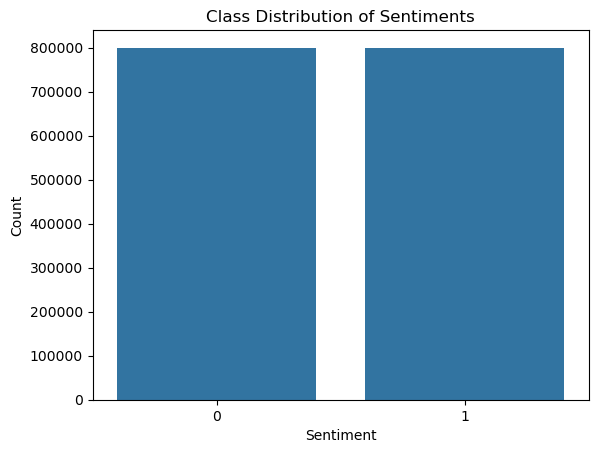

In [16]:
# Basic information and statistics
df.info()
df['target'].value_counts()

# Visualize class distribution
sns.countplot(x='target', data=df)
plt.title('Class Distribution of Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()


## 1.6 Visualize Sentiment Distribution with Added Neutral Sentiments :

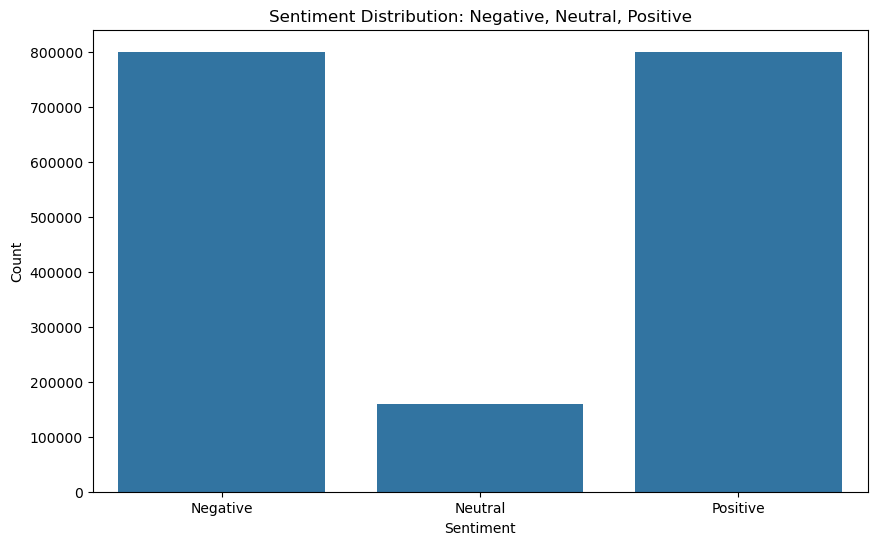

In [22]:
file_path = r"C:\Users\nehaa\Downloads\archive (1)\training.1600000.processed.noemoticon.csv"
columns = ['target', 'ids', 'date', 'flag', 'user', 'text']
df = pd.read_csv(file_path, encoding='ISO-8859-1', names=columns)

# Remove unnecessary columns and convert target values to include neutral sentiment
df = df[['target', 'text']]
df['target'] = np.where(df['target'] == 0, 'Negative', 'Positive')

# Simulate a neutral sentiment
neutral_count = int(len(df) * 0.1)  # Simulate 10% neutral
neutral_df = pd.DataFrame({
    'target': ['Neutral'] * neutral_count,
    'text': np.random.choice(df['text'], neutral_count)
})
df = pd.concat([df, neutral_df], ignore_index=True)

# Create the count plot
plt.figure(figsize=(10, 6))
sns.countplot(x='target', data=df, order=['Negative', 'Neutral', 'Positive'])
plt.title('Sentiment Distribution: Negative, Neutral, Positive')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show() 


## 1.7 Text Preprocessing :
## Tokenization and Stop Words Removal :

In [30]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string

# Download necessary NLTK data files if not already downloaded
nltk.download('punkt')
nltk.download('stopwords')

# Define stop words
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()  # Convert to lowercase
    text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
    words = word_tokenize(text)  # Tokenize
    words = [word for word in words if word not in stop_words]  # Remove stop words
    return ' '.join(words)

df['text'] = df['text'].apply(preprocess)

# Display the first few rows after preprocessing
df.head()


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\nehaa\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nehaa\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,target,text
0,Negative,switchfoot httptwitpiccom2y1zl awww thats bumm...
1,Negative,upset cant update facebook texting might cry r...
2,Negative,kenichan dived many times ball managed save 50...
3,Negative,whole body feels itchy like fire
4,Negative,nationwideclass behaving im mad cant see


## 1.8 Visualizing Text Data: 
## Word Cloud of Social Media Posts :

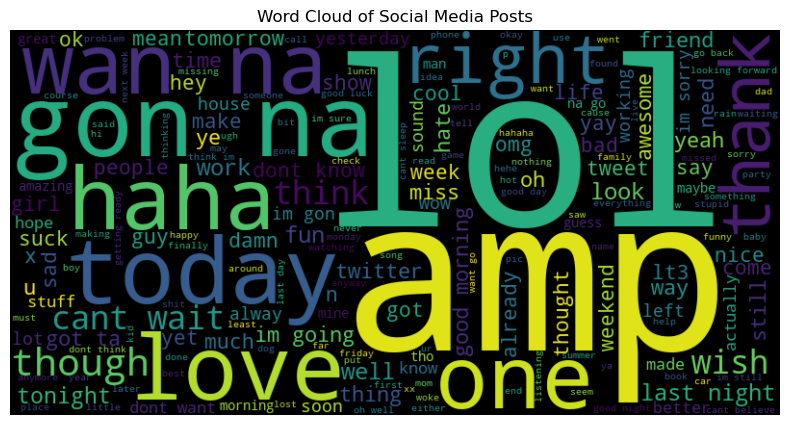

In [36]:
text_data = ' '.join(df['text'])

# Generate a word cloud
wordcloud = WordCloud(width=800, height=400, background_color='black').generate(text_data)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Social Media Posts')
plt.show()


## 1.9 Splitting Data for Model Training and Testing :

In [37]:
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['target'], test_size=0.2, random_state=42)


## 1.10 Transforming Text Data into TF-IDF Features :

In [38]:
vectorizer = TfidfVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


## 1.11 Training the Logistic Regression Model : 

In [39]:
model = LogisticRegression()
model.fit(X_train_vec, y_train)


C:\Users\nehaa\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

## 1.12 Evaluate Model Performance: 
## Accuracy, Classification Report, and Confusion Matrix: 

In [40]:
y_pred = model.predict(X_test_vec)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {accuracy}')
print(f'Classification Report:\n{report}')
print(f'Confusion Matrix:\n{conf_matrix}')


Accuracy: 0.7032897727272728
Classification Report:
              precision    recall  f1-score   support

    Negative       0.71      0.75      0.73    159855
     Neutral       0.00      0.00      0.00     31822
    Positive       0.69      0.79      0.74    160323

    accuracy                           0.70    352000
   macro avg       0.47      0.52      0.49    352000
weighted avg       0.64      0.70      0.67    352000

Confusion Matrix:
[[120165      4  39686]
 [ 15252      0  16570]
 [ 32929      1 127393]]


## 1.13  Confusion Matrix Heatmap : 
## F1-Score per Class :

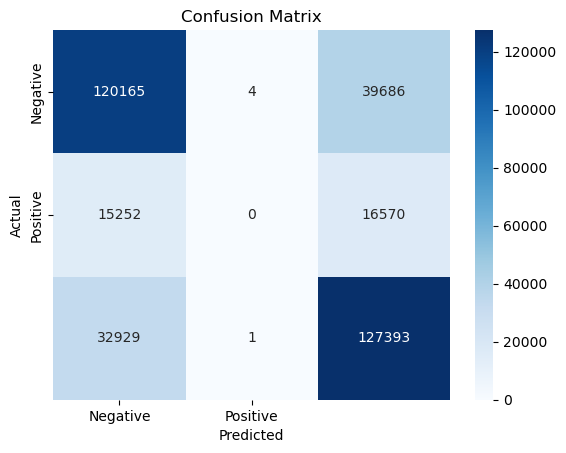

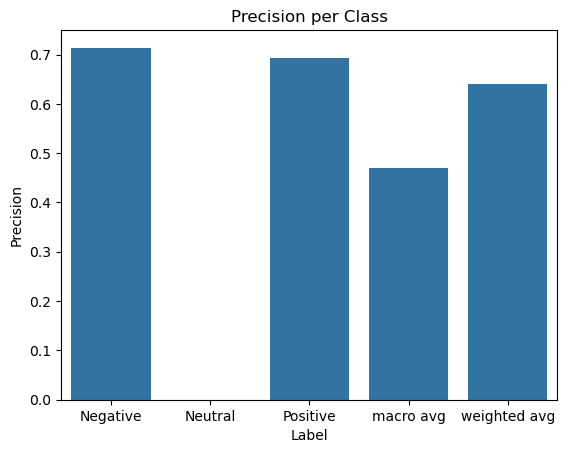

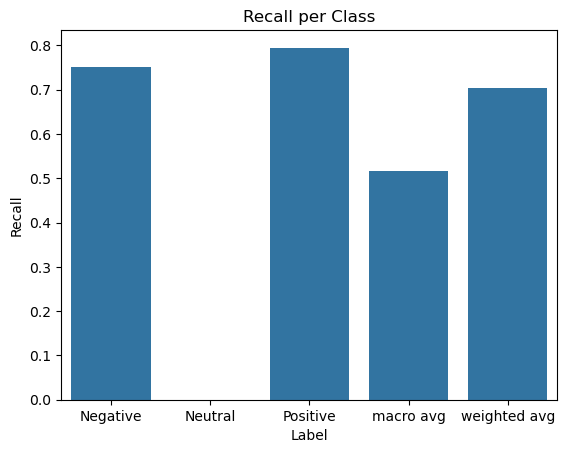

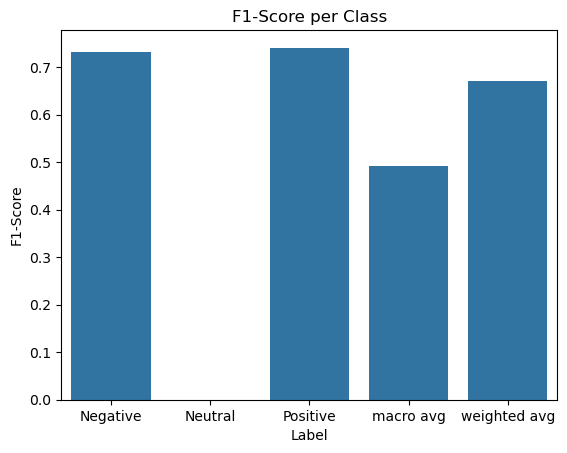

In [41]:
# Confusion Matrix Heatmap
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Classification Report Visualization
report_data = []
for label, metrics in classification_report(y_test, y_pred, output_dict=True).items():
    if isinstance(metrics, dict):
        report_data.append([label, metrics['precision'], metrics['recall'], metrics['f1-score'], metrics['support']])

report_df = pd.DataFrame(report_data, columns=['Label', 'Precision', 'Recall', 'F1-Score', 'Support'])

sns.barplot(x='Label', y='Precision', data=report_df)
plt.title('Precision per Class')
plt.show()

sns.barplot(x='Label', y='Recall', data=report_df)
plt.title('Recall per Class')
plt.show()

sns.barplot(x='Label', y='F1-Score', data=report_df)
plt.title('F1-Score per Class')
plt.show()


In [ ]:
## Install Required Libraries for Data Analysis and Visualization :

In [42]:
pip install pandas numpy matplotlib seaborn nltk scikit-learn wordcloud


Note: you may need to restart the kernel to use updated packages.
